# Sparse-grid contender benchmark — results

**Question.** Which sampler can steer a semi-autonomous NSTX linear-GENE scan when the
target is discontinuous: `sg_lib` (sensitivity-driven), **SG++** (spatially adaptive),
or **GPR**? Objective is to land budget on **max growth rate** *and* **mixed / competing-mode**
regions.

**Answer up front.**

1. No single method does both. `gpr-ucb` owns peaks (7.4x random); `gpr-grad` is the only
   arm that targets the competing-mode band (2.0x random) — and each is *worse than random*
   at the other's job.
2. `sg_lib` never places a point in the top decile of gamma. Not tuning — structural.
3. `gpr-var` (plain uncertainty sampling) is statistically indistinguishable from random.
4. SG++ is unbenchmarked: no `pysgpp` distribution exists for this platform.

Reproduce: `python plot_manifold.py`, `python plot_placement.py`, `python run_pilot.py`.

In [1]:
import json, pathlib, time, warnings
import numpy as np, matplotlib.pyplot as plt

import sys; sys.path.insert(0, str(pathlib.Path.cwd()))
from manifold import Manifold, CAMPAIGN_AXES, BRANCH_NAMES
from arms import design_metrics, score_arm
from run_pilot import CASES, _make_arm

warnings.filterwarnings("ignore")
OUT = pathlib.Path("outputs"); OUT.mkdir(exist_ok=True)
CACHE = OUT / "report_cache.npz"
DIM = len(CAMPAIGN_AXES); NAMES = [a.name for a in CAMPAIGN_AXES]
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
ARMS = ["sglib", "gpr-var", "gpr-ucb", "gpr-grad", "random-nn"]
COL = {a: f"C{i}" for i, a in enumerate(ARMS)}
MIX_T, BUDGET = 0.30, 300
print("axes:", NAMES)

axes: ['Te_ped_scale', 'ne_ped_scale', 'w_Te_scale', 'w_ne_scale', 'Ti_Te', 'ky_scale']


---
## 1. The test manifold

Six coupled axes (the frozen first-campaign electron-channel knobs). Four competing
branches ITG / TEM / KBM / MTM. Difficulty knobs: hybridization width `T`, hard `argmax`
selection, an MTM rational-surface **band gap** (true jump), plus noise and failed runs.

Not a gyrokinetic solve — it reproduces the *structure* of mode competition, not NSTX
growth rates.

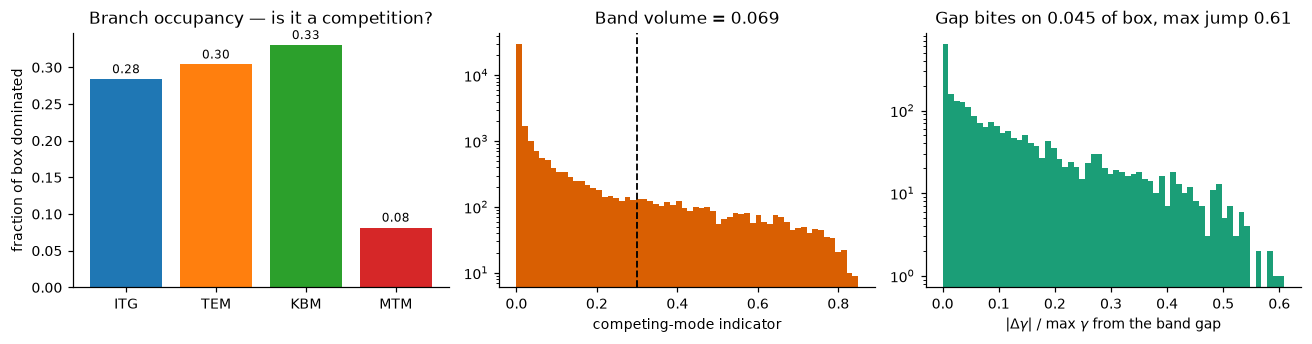

In [2]:
U = np.random.default_rng(7).random((40000, DIM))
ev = Manifold(mode="argmax", align="smooth").evaluate(U)
gap = Manifold(mode="argmax", align="gap").evaluate(U)
occ = np.bincount(ev["label"], minlength=4) / len(U)
band_vol = float(np.mean(ev["mix"] >= MIX_T))
rel = np.abs(gap["gamma"] - ev["gamma"]) / ev["gamma"].max()

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
ax[0].bar(BRANCH_NAMES, occ, color=[f"C{i}" for i in range(4)])
for i, v in enumerate(occ): ax[0].text(i, v + .008, f"{v:.2f}", ha="center", fontsize=8)
ax[0].set_ylabel("fraction of box dominated"); ax[0].set_title("Branch occupancy — is it a competition?")

ax[1].hist(ev["mix"], bins=60, color="#d95f02"); ax[1].set_yscale("log")
ax[1].axvline(MIX_T, color="k", ls="--", lw=1.2)
ax[1].set_xlabel("competing-mode indicator"); ax[1].set_title(f"Band volume = {band_vol:.3f}")

ax[2].hist(rel[rel > 1e-6], bins=60, color="#1b9e77"); ax[2].set_yscale("log")
ax[2].set_xlabel(r"$|\Delta\gamma|$ / max $\gamma$ from the band gap")
ax[2].set_title(f"Gap bites on {np.mean(rel > .01):.3f} of box, max jump {rel.max():.2f}")
for a in ax: a.spines[["right", "top"]].set_visible(False)
plt.tight_layout(); plt.show()

Occupancy is near-uniform by construction (amplitudes grid-searched). MTM's smaller
share is structural: it is a low-$k_y$ mode, so it can only win at the low-$k_y$ end.

The competing-mode band is **thin — 6.9% of the box** — which is exactly why targeting it
is hard and why "space-filling" is not good enough.

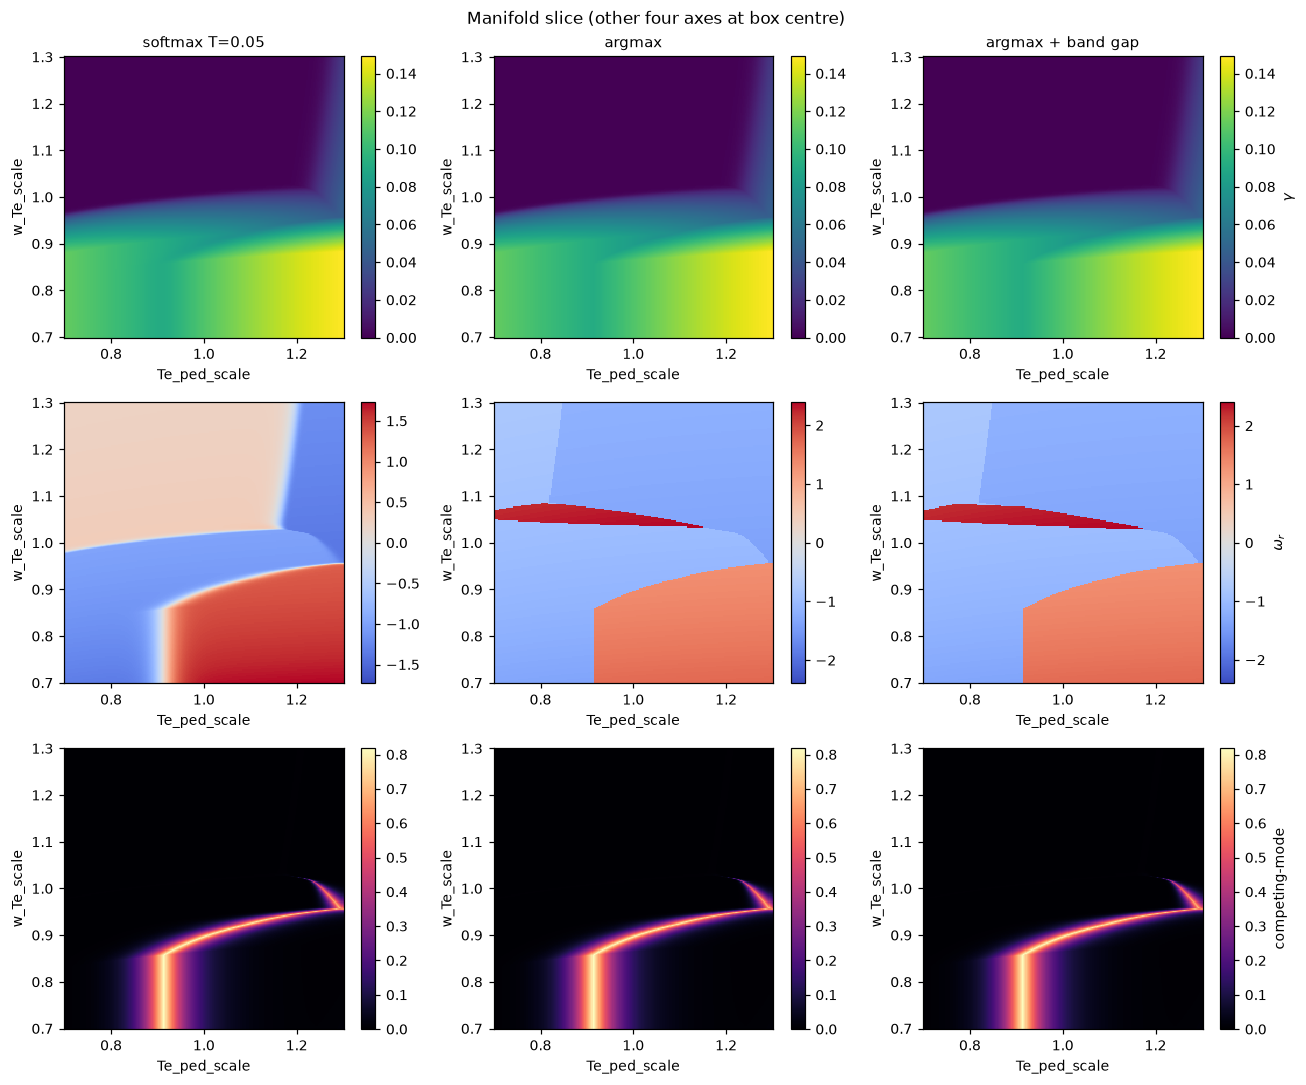

In [3]:
ix, iy = 0, 2                      # Te_ped_scale vs w_Te_scale: carry the kink ridge
gx, gy = np.meshgrid(np.linspace(0, 1, 240), np.linspace(0, 1, 240))
Us = np.full((gx.size, DIM), 0.5); Us[:, ix], Us[:, iy] = gx.ravel(), gy.ravel()
X, Y = CAMPAIGN_AXES[ix].to_phys(gx), CAMPAIGN_AXES[iy].to_phys(gy)
cases = [("softmax T=0.05", dict(mode="softmax", T=.05, align="smooth")),
         ("argmax", dict(mode="argmax", align="smooth")),
         ("argmax + band gap", dict(mode="argmax", align="gap"))]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for j, (title, kw) in enumerate(cases):
    e = Manifold(**kw).evaluate(Us)
    for i, (k, cm, lab) in enumerate([("gamma", "viridis", r"$\gamma$"),
                                      ("omega", "coolwarm", r"$\omega_r$"),
                                      ("mix", "magma", "competing-mode")]):
        Z = e[k].reshape(gx.shape); kw2 = dict(shading="auto", cmap=cm)
        if k == "omega": v = np.abs(Z).max(); kw2.update(vmin=-v, vmax=v)
        pc = axes[i, j].pcolormesh(X, Y, Z, **kw2)
        fig.colorbar(pc, ax=axes[i, j], label=lab if j == 2 else "")
        if i == 0: axes[i, j].set_title(title, fontsize=10)
        axes[i, j].set_xlabel(NAMES[ix]); axes[i, j].set_ylabel(NAMES[iy])
plt.suptitle("Manifold slice (other four axes at box centre)", fontsize=11)
plt.tight_layout(); plt.show()

**Read the middle row.** Under `argmax`, $\omega_r$ is piecewise constant with hard
jumps where the dominant branch flips diamagnetic direction. The red MTM island near
`w_Te_scale` ~ 1.05 is **clipped** by the band gap (right column vs middle) — that is the
discontinuity the whole benchmark is about.

**Bottom row: the competing-mode ridge runs oblique**, not along any axis. Remember that
for section 2.

---
## 2. How each method picks its next points

All three are "adaptive"; none adapt over the same thing.

| arm | refines | granularity | follows an oblique boundary? | failed run |
|---|---|---|---|---|
| `sglib` | multiindices (subspaces), by spectral variance | a whole subspace, atomic | **no** — axis-aligned | hole in interpolant |
| `sgpp-*` | grid points, by hierarchical surplus | one point | partly | hole in interpolant |
| `gpr-*` | nothing prescribed — scores a free pool | one point, anywhere | **yes** | dropped sample |

Designs only here — no `predict()` — so this is fast even for arms whose interpolant is
expensive to query.

In [4]:
def collect(case="argmax+gap", out="gamma", budget=BUDGET):
    if CACHE.exists():
        z = np.load(CACHE, allow_pickle=True)
        return {k: z[k] for k in z.files}
    m = Manifold(out=out, **CASES[case]); store = {}
    for nm in ARMS:
        try: arm = _make_arm(nm)
        except ImportError as e: print(f"[skip] {nm}: {e}"); continue
        oracle = m.oracle(out); t0 = time.perf_counter()
        arm.fit(oracle, m.dim, budget)
        store[nm] = oracle.design
        print(f"{nm:11s} n={oracle.n_evals:4d}  {time.perf_counter()-t0:5.1f}s")
    np.savez(CACHE, **store); return store

m_gap = Manifold(out="gamma", **CASES["argmax+gap"])
designs = collect()
info = {nm: m_gap.evaluate(D) for nm, D in designs.items()}
print("\narms:", list(designs))


arms: ['sglib', 'gpr-var', 'gpr-ucb', 'gpr-grad', 'random-nn']


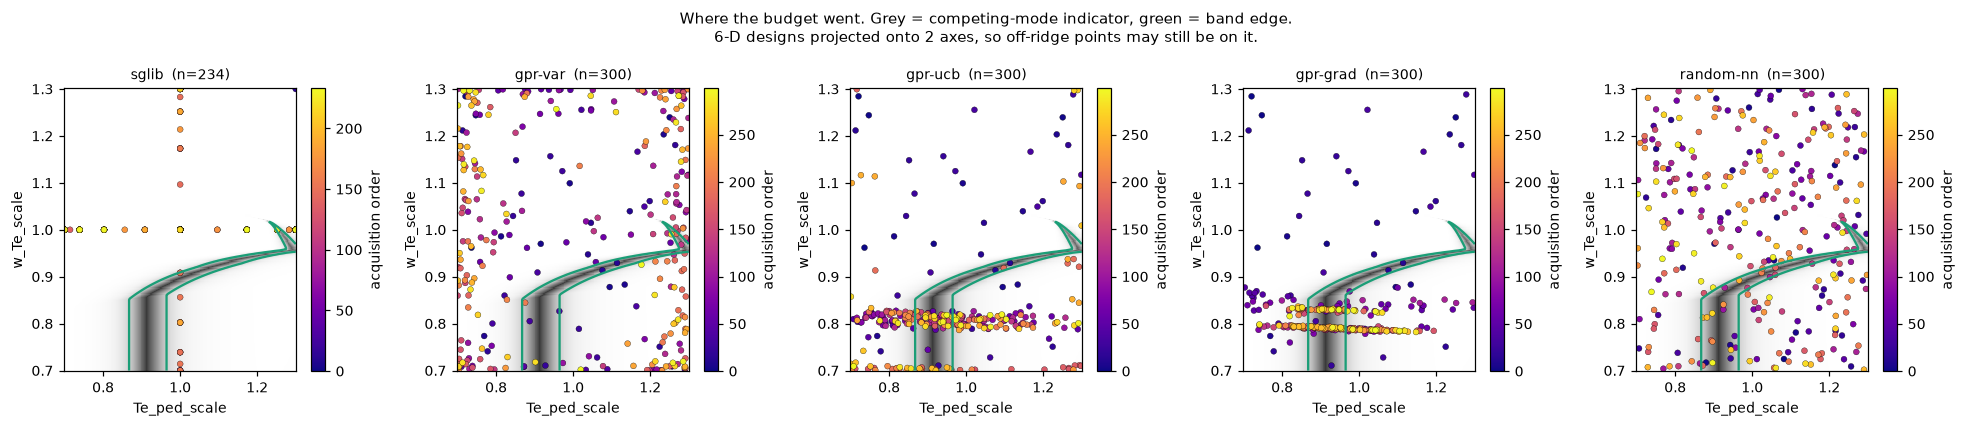

In [5]:
MIXg = m_gap.evaluate(Us)["mix"].reshape(gx.shape)
n = len(designs)
fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 3.9), squeeze=False)
for ax, (nm, D) in zip(axes[0], designs.items()):
    ax.pcolormesh(X, Y, MIXg, shading="auto", cmap="Greys", vmin=0, vmax=1)
    ax.contour(X, Y, MIXg, levels=[MIX_T], colors="#1b9e77", linewidths=1.5)
    sc = ax.scatter(CAMPAIGN_AXES[ix].to_phys(D[:, ix]), CAMPAIGN_AXES[iy].to_phys(D[:, iy]),
                    c=np.arange(len(D)), cmap="plasma", s=15, edgecolor="k", lw=.2)
    fig.colorbar(sc, ax=ax, label="acquisition order")
    ax.set_title(f"{nm}  (n={len(D)})", fontsize=9)
    ax.set_xlabel(NAMES[ix]); ax.set_ylabel(NAMES[iy])
plt.suptitle("Where the budget went. Grey = competing-mode indicator, green = band edge.\n"
             "6-D designs projected onto 2 axes, so off-ridge points may still be on it.",
             fontsize=10)
plt.tight_layout(); plt.show()

**This is the headline figure.**

- **`sglib` draws a sparse cross** — axis-aligned lines through the box centre. The ridge
  runs diagonally; the design runs along the axes. They intersect almost nowhere. This is
  what "axis-aligned refinement cannot chase an oblique boundary" looks like.
- **`gpr-var` evacuates the interior** and piles onto the box edges: pointwise predictive
  variance is maximal at the boundary in 6-D. A known pathology, and the reason it degrades
  to random.
- **`gpr-ucb`** finds the high-$\gamma$ stripe (low `w_Te_scale` = steep gradient) and camps.
- **`gpr-grad`** lays points *along* the feature — the only design that tracks the ridge.

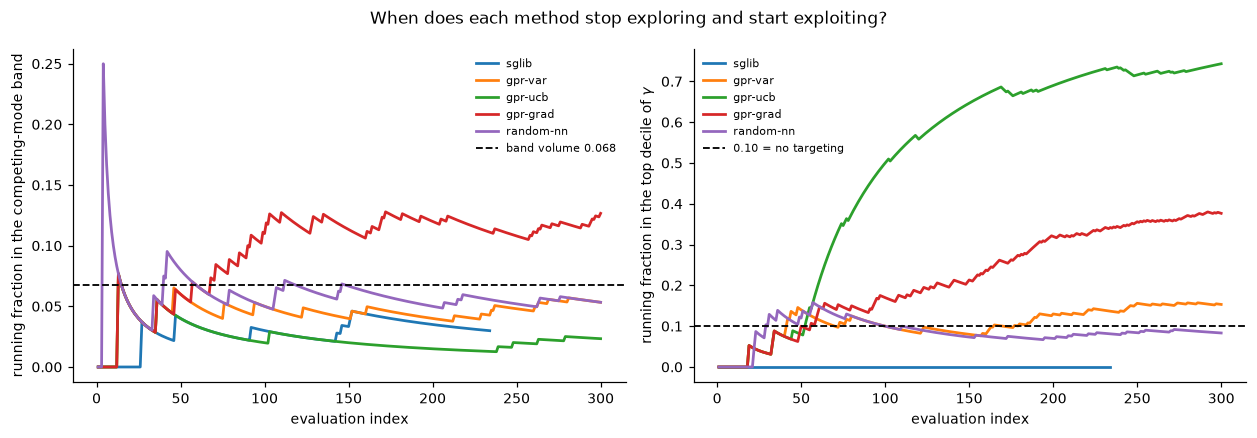

In [6]:
ref = np.random.default_rng(4).random((6000, DIM)); er = m_gap.evaluate(ref)
band_vol = float(np.mean(er["mix"] >= MIX_T)); q90 = float(np.quantile(np.abs(er["gamma"]), .9))
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
for nm, D in designs.items():
    e = info[nm]; k = np.arange(1, len(D) + 1)
    ax[0].plot(k, np.cumsum(e["mix"] >= MIX_T) / k, lw=1.8, color=COL[nm], label=nm)
    ax[1].plot(k, np.cumsum(np.abs(e["gamma"]) >= q90) / k, lw=1.8, color=COL[nm], label=nm)
ax[0].axhline(band_vol, color="k", ls="--", lw=1.2, label=f"band volume {band_vol:.3f}")
ax[1].axhline(.10, color="k", ls="--", lw=1.2, label="0.10 = no targeting")
ax[0].set_ylabel("running fraction in the competing-mode band")
ax[1].set_ylabel(r"running fraction in the top decile of $\gamma$")
for a in ax:
    a.set_xlabel("evaluation index"); a.legend(frameon=False, fontsize=7)
    a.spines[["right", "top"]].set_visible(False)
plt.suptitle("When does each method stop exploring and start exploiting?", fontsize=11)
plt.tight_layout(); plt.show()

Both GPR arms track random for the first ~40–50 evaluations — that is the Latin-hypercube
initialisation — then diverge sharply once acquisition takes over.

**`sglib` is flat at exactly zero on the right panel for the entire run.** It never places a
single point in the top decile of $\gamma$.

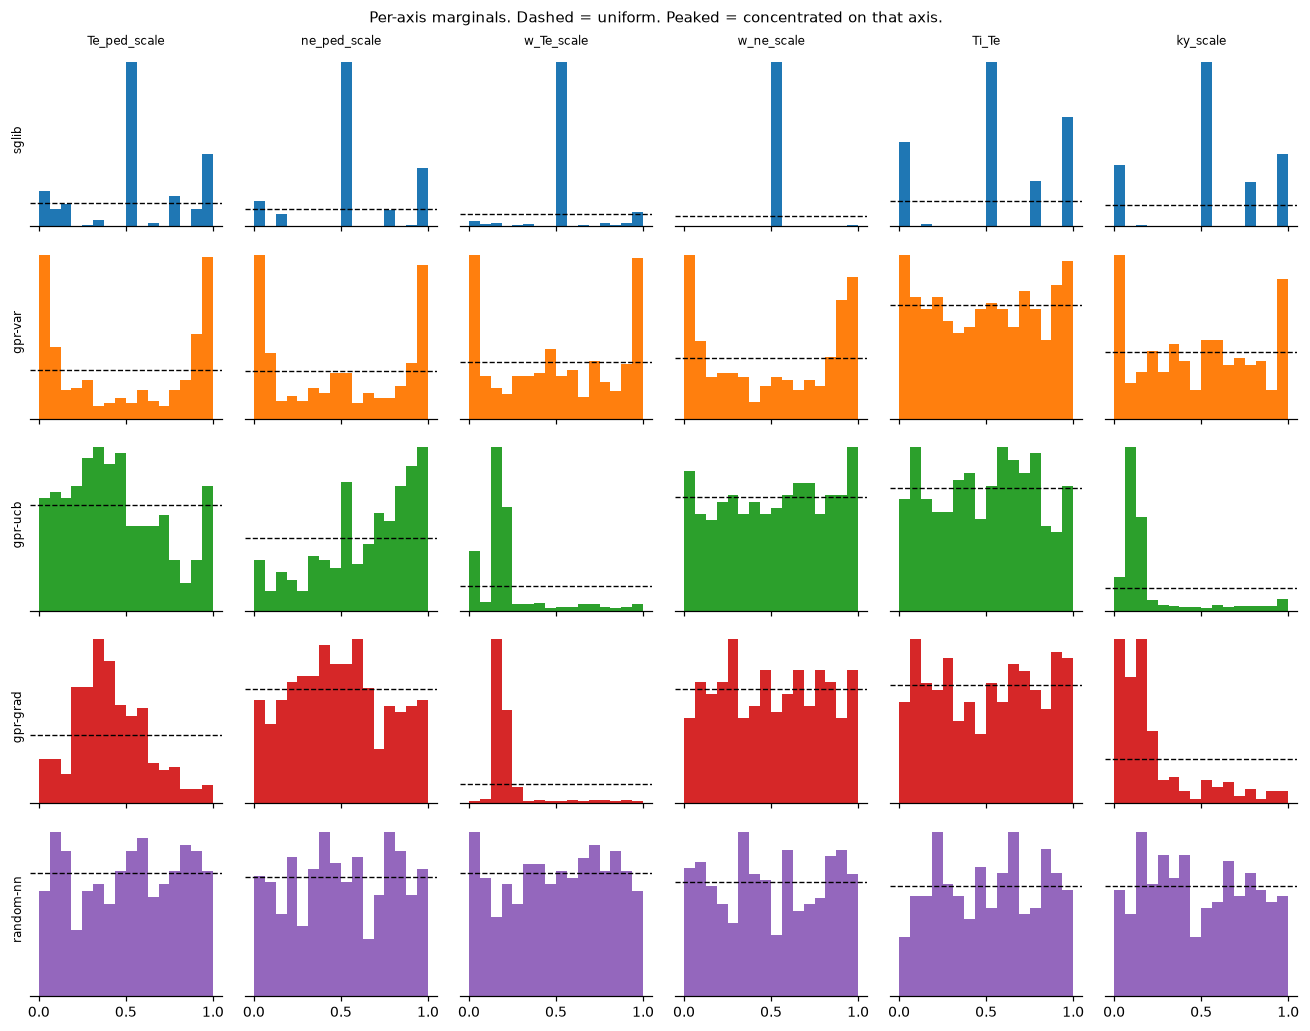

In [7]:
fig, axes = plt.subplots(len(designs), DIM, figsize=(2.0 * DIM, 1.9 * len(designs)),
                         squeeze=False, sharex=True)
for i, (nm, D) in enumerate(designs.items()):
    for j in range(DIM):
        a = axes[i, j]
        a.hist(D[:, j], bins=16, range=(0, 1), color=COL[nm])
        a.axhline(len(D) / 16, color="k", ls="--", lw=.9)
        if i == 0: a.set_title(NAMES[j], fontsize=8)
        if j == 0: a.set_ylabel(nm, fontsize=8)
        a.set_yticks([]); a.spines[["right", "top", "left"]].set_visible(False)
plt.suptitle("Per-axis marginals. Dashed = uniform. Peaked = concentrated on that axis.",
             fontsize=10)
plt.tight_layout(); plt.show()

**Independent agreement on which axes matter.** `sglib` holds `w_ne_scale` at a single
spike at 0.5 — it never varied that axis at all (pruned at level 2). `gpr-grad` leaves
`w_ne_scale` and `Ti_Te` flat while spiking on `w_Te_scale` and low `ky_scale`.

Two unrelated mechanisms — spectral variance scores and fitted GP length scales — ranking
the same two axes as irrelevant is a real cross-check on the Stage-A pruning.

---
## 3. Scoreboard — targeting vs. coverage

`band_lift` = in-band design fraction / band volume. **1.0 = no targeting.**
`frac_peak` = fraction in the top decile of $\gamma$. **0.10 = no targeting.**

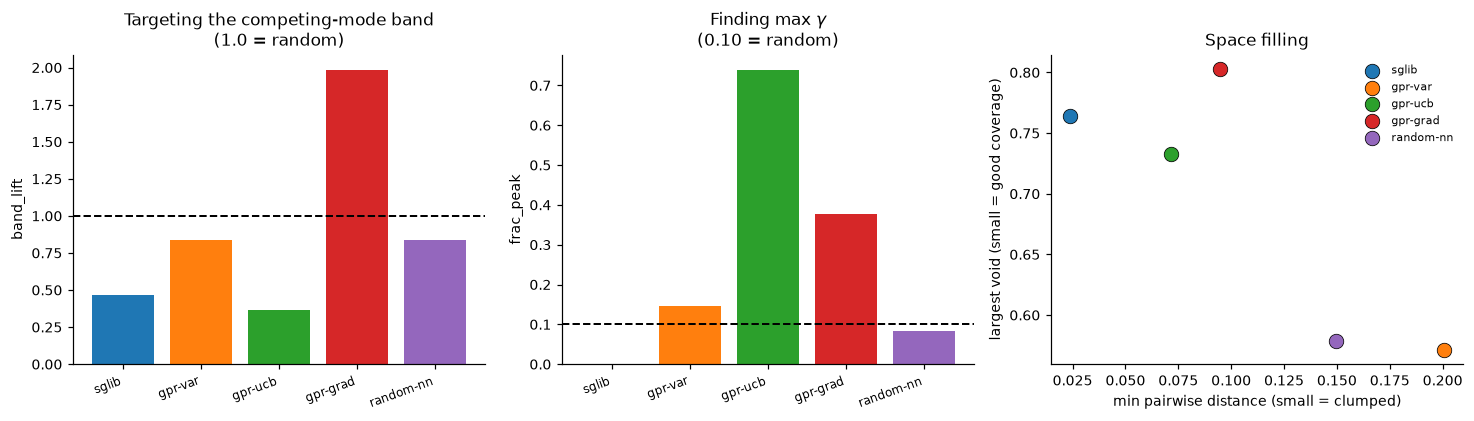

In [8]:
dm = {nm: design_metrics(D, m_gap, mix_thresh=MIX_T) for nm, D in designs.items()}
names = list(dm); xs = np.arange(len(names))

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.9))
ax[0].bar(xs, [dm[n]["band_lift"] for n in names], color=[COL[n] for n in names])
ax[0].axhline(1.0, color="k", ls="--", lw=1.3)
ax[0].set_ylabel("band_lift"); ax[0].set_title("Targeting the competing-mode band\n(1.0 = random)")

ax[1].bar(xs, [dm[n]["frac_peak"] for n in names], color=[COL[n] for n in names])
ax[1].axhline(0.10, color="k", ls="--", lw=1.3)
ax[1].set_ylabel("frac_peak"); ax[1].set_title(r"Finding max $\gamma$" + "\n(0.10 = random)")

for n in names:
    ax[2].scatter(dm[n]["min_dist"], dm[n]["hole"], s=90, color=COL[n], label=n,
                  edgecolor="k", lw=.5)
ax[2].set_xlabel("min pairwise distance (small = clumped)")
ax[2].set_ylabel("largest void (small = good coverage)")
ax[2].set_title("Space filling"); ax[2].legend(frameon=False, fontsize=7)
for a in ax[:2]:
    a.set_xticks(xs); a.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
for a in ax: a.spines[["right", "top"]].set_visible(False)
plt.tight_layout(); plt.show()

**The trade-off is the result.** `gpr-ucb` is the only arm well above the peak line and
is *below* random on the band. `gpr-grad` is the only arm above the band line. You cannot
get both from one of these acquisitions.

**`sglib` is worst on both**, and the right panel shows why it is not even buying coverage
in exchange: it has simultaneously the *most clumping* (nested nodes land nearly on top of
one another) and the *largest void*.

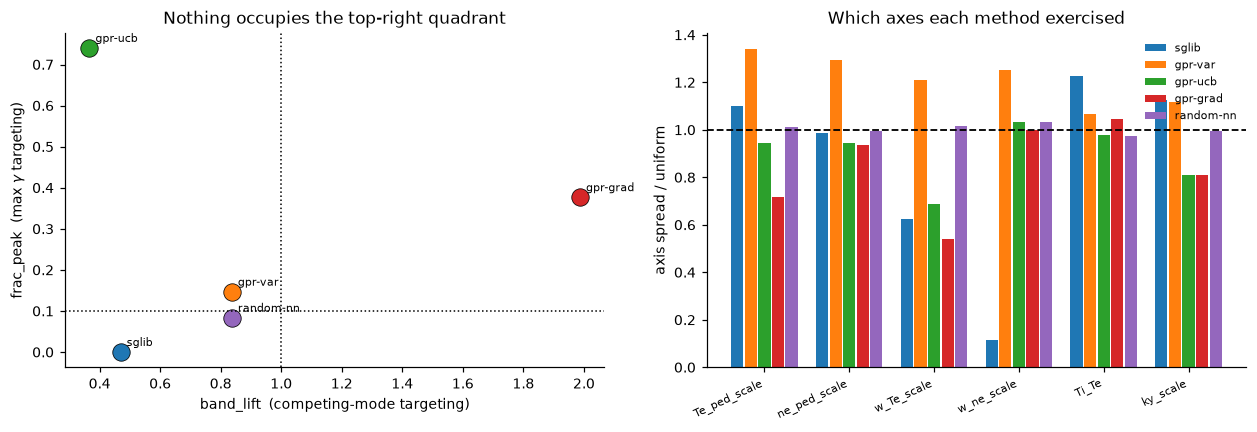

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
for n in names:
    ax[0].scatter(dm[n]["band_lift"], dm[n]["frac_peak"], s=130, color=COL[n],
                  edgecolor="k", lw=.5, label=n)
    ax[0].annotate(n, (dm[n]["band_lift"], dm[n]["frac_peak"]), fontsize=7,
                   xytext=(4, 4), textcoords="offset points")
ax[0].axhline(.10, color="k", ls=":", lw=1); ax[0].axvline(1.0, color="k", ls=":", lw=1)
ax[0].set_xlabel("band_lift  (competing-mode targeting)")
ax[0].set_ylabel(r"frac_peak  (max $\gamma$ targeting)")
ax[0].set_title("Nothing occupies the top-right quadrant")

w = .8 / len(names)
for i, n in enumerate(names):
    ax[1].bar(np.arange(DIM) + i * w, dm[n]["axis_spread"], w * .9, color=COL[n], label=n)
ax[1].axhline(1.0, color="k", ls="--", lw=1.2)
ax[1].set_xticks(np.arange(DIM) + .4 - w / 2)
ax[1].set_xticklabels(NAMES, rotation=25, ha="right", fontsize=7)
ax[1].set_ylabel("axis spread / uniform"); ax[1].set_title("Which axes each method exercised")
ax[1].legend(frameon=False, fontsize=7)
for a in ax: a.spines[["right", "top"]].set_visible(False)
plt.tight_layout(); plt.show()

**Left panel is the whole argument.** The top-right quadrant — target peaks *and* mode
competition — is **empty**. Your stated objective needs a point in it.

Right panel: `sglib`'s `w_ne_scale` spread is ~0.11 vs 1.0 for uniform — the axis was frozen.

---
## 4. Accuracy vs. budget

Errors are scored against **clean truth** even when the arm trained on noisy, partly-failed
observations, so fitting noise is punished. `nrmse` is normalized by the QoI range so
$\gamma$ and $\omega_r$ compare.

In [10]:
def sweep(case, out, budgets, arms, n_test=600):
    f = OUT / f"report_sweep_{case.replace('+','_')}_{out}.json"
    if f.exists(): return json.loads(f.read_text())
    m = Manifold(out=out, **CASES[case]); test = m.test_set(n=n_test); rows = []
    for b in budgets:
        for nm in arms:
            try: arm = _make_arm(nm)
            except ImportError: continue
            try: s = score_arm(arm, m, out=out, budget=b, test=test, mix_thresh=MIX_T)
            except Exception as e: print(f"[fail] {nm}@{b}: {e}"); continue
            rows.append(dict(arm=nm, budget=b, **{k: s.as_dict()[k] for k in
                        ("n_evals","nrmse","rmse_mixed","rmse_calm","n_failed","fit_seconds")}))
            print(f"  {case}/{out} {nm:11s} b={b:4d} n={s.n_evals:4d} nRMSE={s.nrmse:.3e}")
    f.write_text(json.dumps(rows, indent=1)); return rows

BUDGETS = [100, 300]   # sg_lib exhausts its active set near 234, so 400 is not budget-matched
rows = {c: {o: sweep(c, o, BUDGETS, ARMS) for o in ("gamma", "omega")}
        for c in ("argmax+gap", "argmax+gap+noisy")}
print("done")

  argmax+gap/gamma sglib       b= 100 n= 100 nRMSE=1.580e-01


  argmax+gap/gamma gpr-var     b= 100 n= 100 nRMSE=1.255e-01


  argmax+gap/gamma gpr-ucb     b= 100 n= 100 nRMSE=1.514e-01


  argmax+gap/gamma gpr-grad    b= 100 n= 100 nRMSE=1.769e-01
  argmax+gap/gamma random-nn   b= 100 n= 100 nRMSE=1.538e-01


  argmax+gap/gamma sglib       b= 300 n= 234 nRMSE=1.302e-01


...

  argmax+gap+noisy/omega gpr-grad    b= 100 n= 100 nRMSE=1.974e-01
  argmax+gap+noisy/omega random-nn   b= 100 n= 100 nRMSE=2.417e-01


  argmax+gap+noisy/omega sglib       b= 300 n= 299 nRMSE=2.507e-01


  argmax+gap+noisy/omega gpr-var     b= 300 n= 300 nRMSE=1.451e-01


  argmax+gap+noisy/omega gpr-ucb     b= 300 n= 300 nRMSE=1.828e-01


  argmax+gap+noisy/omega gpr-grad    b= 300 n= 300 nRMSE=1.917e-01
  argmax+gap+noisy/omega random-nn   b= 300 n= 300 nRMSE=2.233e-01
done


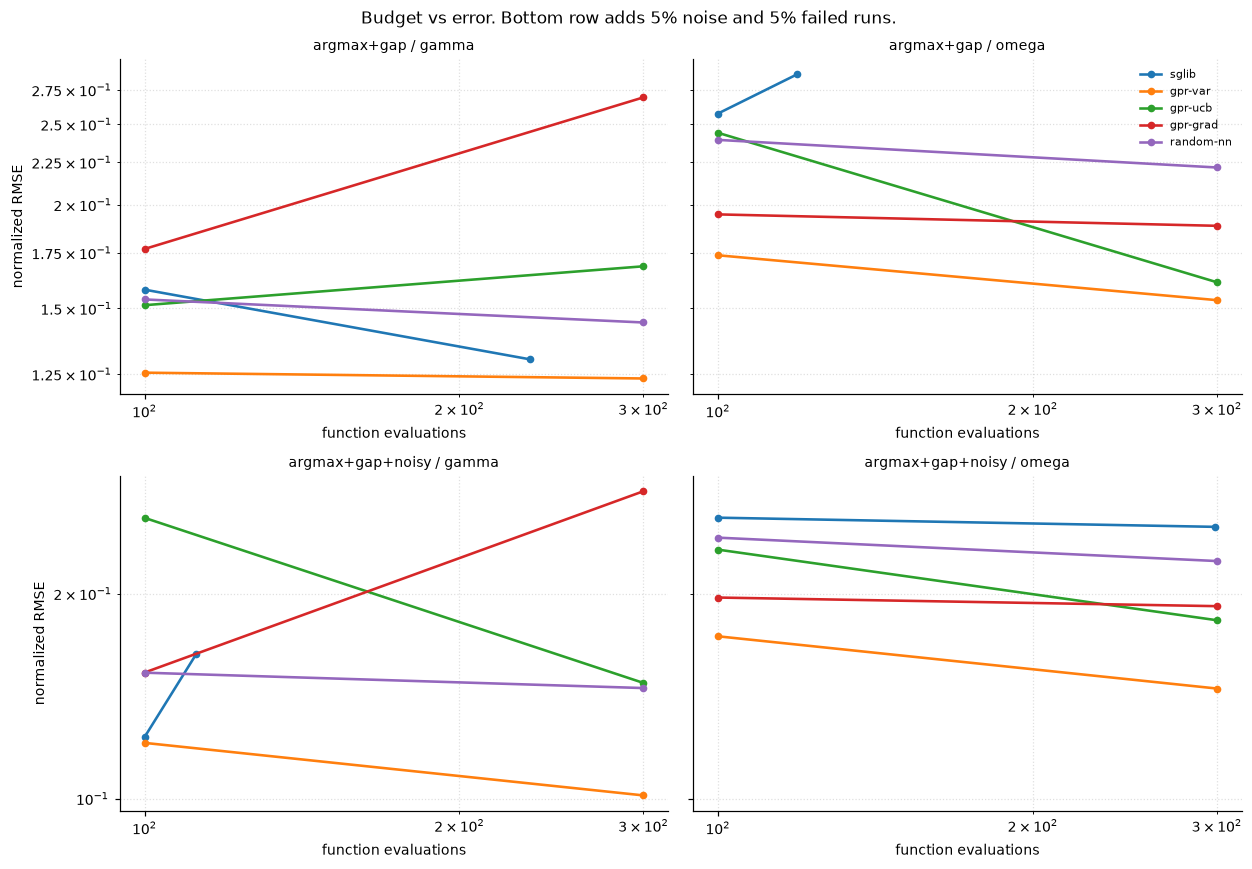

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8), sharey="row")
for r, case in enumerate(("argmax+gap", "argmax+gap+noisy")):
    for c, out in enumerate(("gamma", "omega")):
        a = axes[r, c]
        for nm in ARMS:
            sel = sorted([x for x in rows[case][out] if x["arm"] == nm],
                         key=lambda x: x["n_evals"])
            if sel: a.loglog([x["n_evals"] for x in sel], [x["nrmse"] for x in sel],
                             "o-", color=COL[nm], lw=1.7, ms=4, label=nm)
        a.set_title(f"{case} / {out}", fontsize=9)
        a.set_xlabel("function evaluations"); a.grid(True, which="both", ls=":", alpha=.4)
        a.spines[["right", "top"]].set_visible(False)
        if c == 0: a.set_ylabel("normalized RMSE")
axes[0, 1].legend(frameon=False, fontsize=7)
plt.suptitle("Budget vs error. Bottom row adds 5% noise and 5% failed runs.", fontsize=11)
plt.tight_layout(); plt.show()

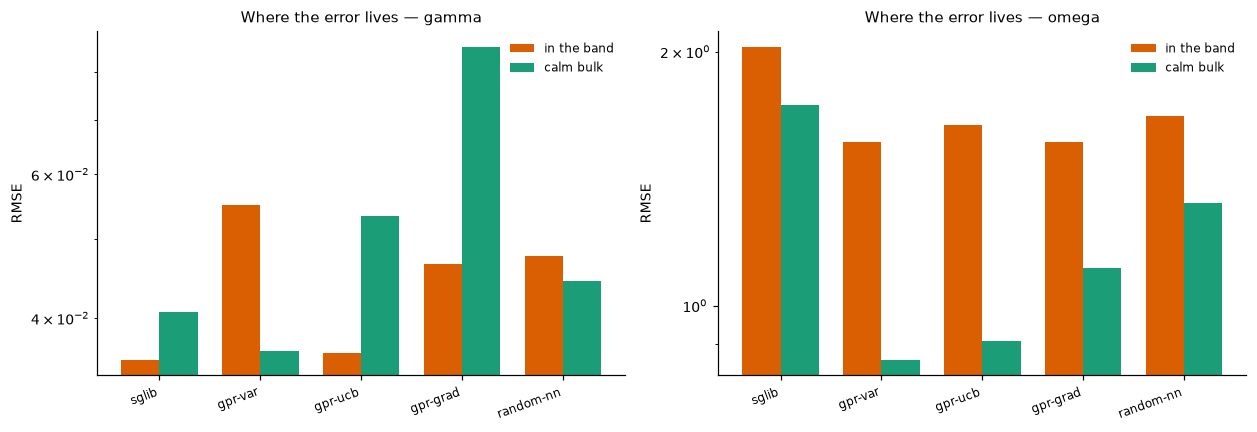

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
for c, out in enumerate(("gamma", "omega")):
    sel = [x for x in rows["argmax+gap"][out] if x["budget"] == max(BUDGETS)]
    nm_ = [x["arm"] for x in sel]; xs_ = np.arange(len(sel)); w = .38
    ax[c].bar(xs_ - w/2, [x["rmse_mixed"] for x in sel], w, color="#d95f02", label="in the band")
    ax[c].bar(xs_ + w/2, [x["rmse_calm"] for x in sel], w, color="#1b9e77", label="calm bulk")
    ax[c].set_xticks(xs_); ax[c].set_xticklabels(nm_, rotation=20, ha="right", fontsize=8)
    ax[c].set_yscale("log"); ax[c].set_title(f"Where the error lives — {out}", fontsize=10)
    ax[c].set_ylabel("RMSE"); ax[c].legend(frameon=False, fontsize=8)
    ax[c].spines[["right", "top"]].set_visible(False)
plt.tight_layout(); plt.show()

Error in the competing-mode band vs the calm bulk, at the largest budget. Average
accuracy hides the failure: the band is thin, so an arm can post a fine `nrmse` while being
wrong exactly where the sensitivity analysis needs to be right.

---
## 5. Findings

1. **The objective needs two acquisitions or one blended one.** Peak-seeking and
   competing-mode-seeking are won by different arms, and each is worse than random at the
   other's job. Proposed fix: `sigma * (w1*|grad mu| + w2*mu_norm)`, weights a physics call.
2. **`sg_lib` is structurally wrong for this target.** Axis-aligned refinement vs an oblique
   ridge; zero points in the top-$\gamma$ decile; worst clumping *and* worst coverage. Its
   value is the free Sobol/axis-pruning readout, not the interpolant. Consistent with the
   method author's own assessment.
3. **Plain uncertainty sampling is not worth its cost** — `gpr-var` ties random while pushing
   points to box corners.
4. **Both methods independently prune the same axes** (`w_ne_scale`, `Ti_Te`), which is a
   usable Stage-A result on its own.

## Bugs found while building

- **sg_lib empty-step trap (mine, ~20x budget under-spend).**
  `do_one_adaption_step_preproc()` returns only the *newly admissible* successors of the
  index it retires — often none. Reading empty as "converged" stopped the method after 3
  steps / **10 evaluations of a 200 budget**, silently. The reference script hides this by
  looping a fixed step count. Guarded by `tests/test_arms.py::test_sglib_spends_a_real_budget`.
- **GPR length scales pinned to both sklearn default bounds** `(1e-2, 1e2)`, silently meaning
  "axis irrelevant" / "varies faster than resolvable". Widened to `(1e-3, 1e4)`.

## Limits — read before trusting any of this

- **SG++ is unbenchmarked.** No `pysgpp` distribution for CPython 3.13 on Windows
  (`pysgpp`, `sgpp`, `SGpp` all resolve to nothing); needs a source build with SWIG
  bindings. Its arm is written and its control flow is tested against a mock, but the
  **pysgpp API signatures are unverified**. This is the biggest hole: SG++ is the arm Ionut
  named for discontinuities, and its niche is exactly what `gpr-grad` currently wins.
- **The manifold is not a gyrokinetic solve.** Coefficients are plausible, not calibrated.
- **One seed, one case for placement.** No error bars; treat rankings as indicative.
- **`sg_lib` exhausts its active set at ~234 evaluations** at `tol=1e-6` in 6-D and stops
  regardless of remaining budget, so above that the comparison is not budget-matched.
- **`sg_lib`'s interpolant is slow to query** — `eval_operation_sg` is a per-point Python
  loop, ~40 s per 300 test points at 234 subspaces.
- Ionut's promised discontinuity code **has not arrived**: `upstream/main` is identical to
  `origin/main` at one commit.